In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
TRAIN_DIR = "../data/alphabet/raw/train"
TEST_DIR = "../data/alphabet/raw/test"
MODEL_SAVE_PATH = "../models/alphabet/alphabet_cnn.keras"

IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
SEED = 42

In [3]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 10490 files belonging to 24 classes.
Found 1800 files belonging to 24 classes.


In [4]:
class_names = train_ds.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Number of classes: 24


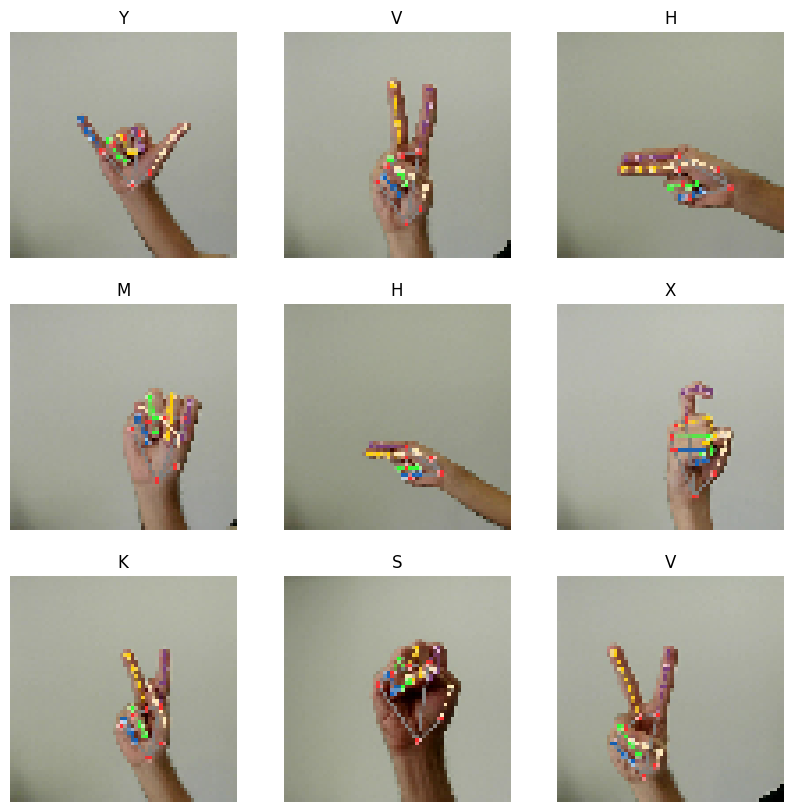

In [5]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,296 (2.62 MB)

 Trainable params: 686,296 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.4267 - loss: 1.8760 - val_accuracy: 0.8167 - val_loss: 0.5562
Epoch 2/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.8175 - loss: 0.5355 - val_accuracy: 0.9394 - val_loss: 0.2028
Epoch 3/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8990 - loss: 0.2896 - val_accuracy: 0.9556 - val_loss: 0.1443
Epoch 4/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 25s 77ms/step - accuracy: 0.9350 - loss: 0.1840 - val_accuracy: 0.9628 - val_loss: 0.1250
Epoch 5/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.9503 - loss: 0.1415 - val_accuracy: 0.9689 - val_loss: 0.1066
Epoch 6/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.9641 - loss: 0.1008 - val_accuracy: 0.9589 - val_loss: 0.1414
Epoch 7/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9663 - loss: 0.0961 - val_accuracy: 0.9633 - val_loss: 0.1472
Epoch 8/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9794 - loss: 0.0615 - val_

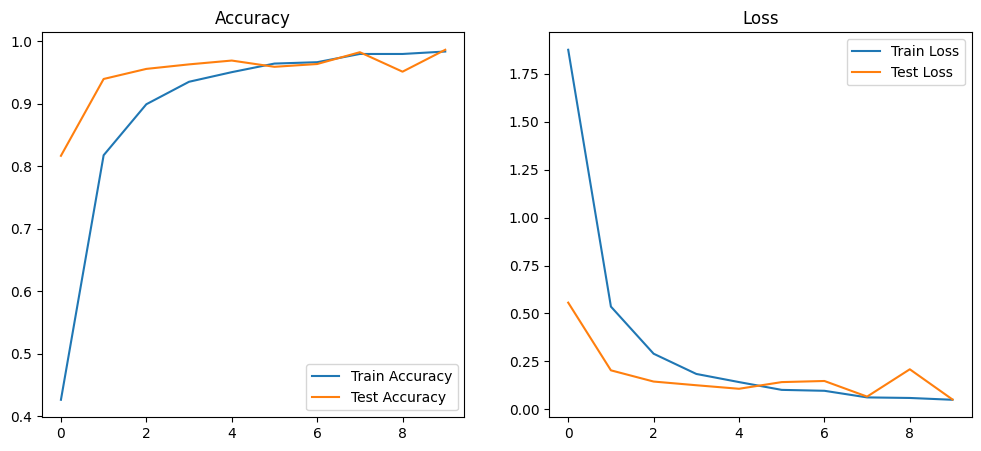

In [10]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Test Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Test Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9861 - loss: 0.0505 
Test accuracy: 0.9861


In [12]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [13]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

           A       1.00      0.89      0.94        75
           B       1.00      1.00      1.00        75
           C       1.00      1.00      1.00        75
           D       1.00      0.97      0.99        75
           E       0.96      0.99      0.97        75
           F       1.00      1.00      1.00        75
           G       1.00      1.00      1.00        75
           H       1.00      1.00      1.00        75
           I       0.97      1.00      0.99        75
           K       1.00      0.97      0.99        75
           L       1.00      1.00      1.00        75
           M       0.96      0.99      0.97        75
           N       0.99      0.99      0.99        75
           O       1.00      1.00      1.00        75
           P       1.00      1.00      1.00        75
           Q       1.00      0.88      0.94        75
           R       1.00      1.00      1.00        75
           S       0.95    

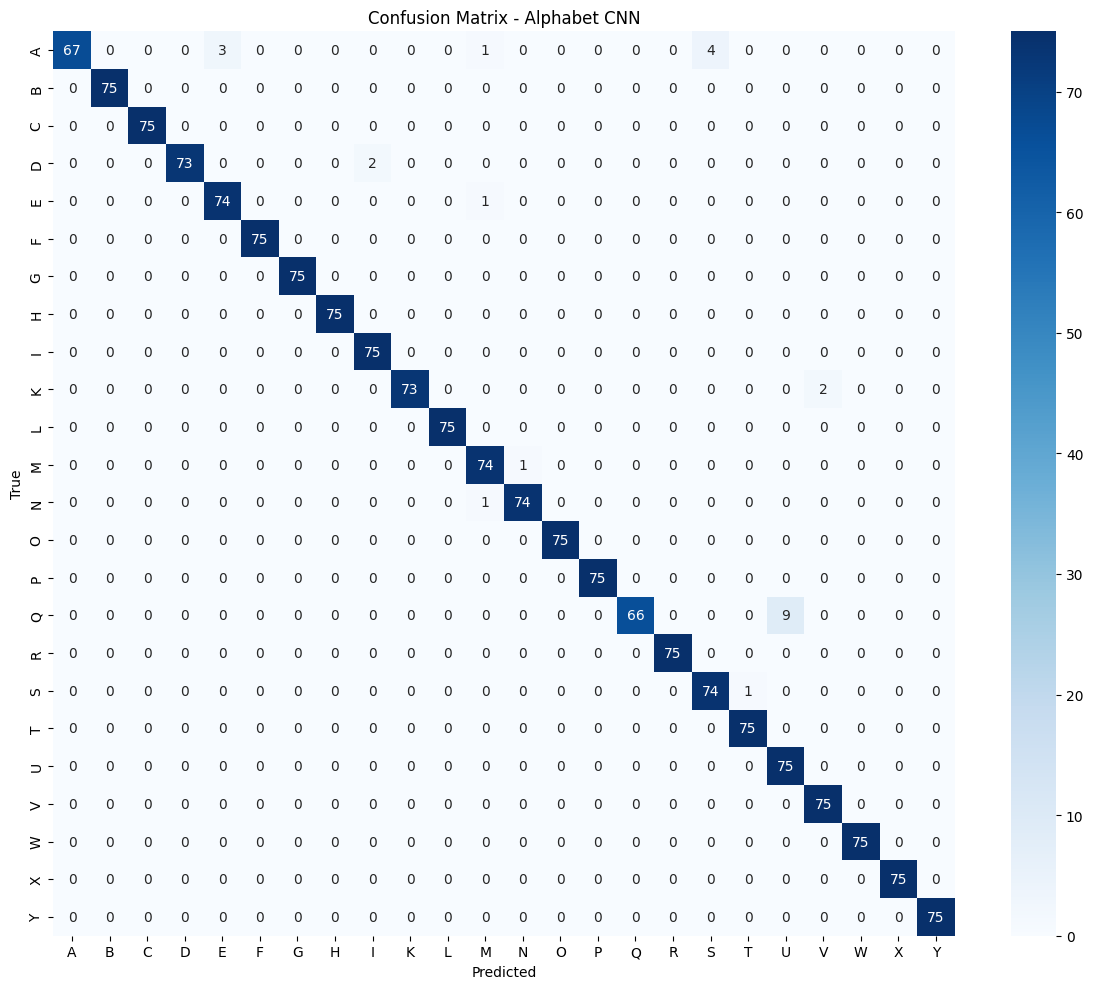

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Alphabet CNN")
plt.tight_layout()
plt.show()

In [15]:
os.makedirs("../models/alphabet", exist_ok=True)
model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: ../models/alphabet/alphabet_cnn.keras
